# 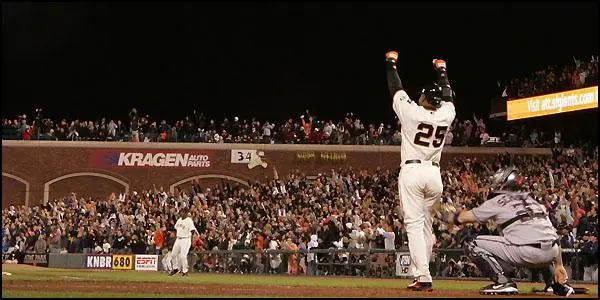

In [1]:
if not 'statsapi' in globals():
    !pip install -q MLB-StatsAPI
!pip install -q python-mlb-statsapi
!pip install -q pandas
!pip install -q numpy
!pip install -q tabulate
import datetime
from datetime import datetime, timezone,timedelta
import statsapi
import mlbstatsapi
import pandas as pd
import numpy as np
import os
from datetime import datetime, timezone

RUN_DATE = os.getenv('RUN_DATE') or datetime.now(timezone.utc).date().isoformat()
mlb = mlbstatsapi.Mlb()

def home_run_getter(player_name):
    try:
        player_name = player_name
        player_id = mlb.get_people_id(player_name)[0]
        stats = mlb.get_player_stats(
            player_id,
            stats=['season'],
            groups=['hitting'],
            season=2026
        )

        # Access the data
        if 'hitting' in stats and 'season' in stats['hitting']:
            for split in stats['hitting']['season'].splits:
                s = split.stat.model_dump(exclude_none=True)
                hrs = s.get('home_runs')
                return hrs
        else:
            print("No season hitting stats found.")
            return 0
    except Exception as e:
        print(f"Error occurred while fetching home run data for {player_name}: {e}")
        return 0
    
    
def HBP_getter(player_name):
    try:
        player_name = player_name
        player_id = mlb.get_people_id(player_name)[0]
        stats = mlb.get_player_stats(
            player_id,
            stats=['season'],
            groups=['hitting'],
            season=2026
        )
        # Access the data
        if 'hitting' in stats and 'season' in stats['hitting']:
            for split in stats['hitting']['season'].splits:
                s = split.stat.model_dump(exclude_none=True)
                hbp = s.get('hit_by_pitch')
                return hbp
        else:
            print("No season hitting stats found.")
            return 0
    except Exception as e:
        print(player_name)
        return 0

ethan_team = [
    "Cal Raleigh",
    "Junior Caminero",
    "Brent Rooker",
    "Gunnar Henderson",
    "Bryce Harper",
    "Vladimir Guerrero Jr.",
    "Nolan Gorman",
    "Wyatt Langford",
    "Jackson Merrill",
    "Corbin Carroll",
    "Caleb Durbin"
]

bo_team = [
    "Shohei Ohtani",
    "Pete Alonso",
    "Munetaka Murakami",
    "Ronald Acuña Jr.",
    "Manny Machado",
    "Julio Rodríguez",
    "Francisco Lindor",
    "Brandon Lowe",
    "Taylor Ward",
    "Salvador Perez",
    "Ty France"
]

dave_team = [
    "Aaron Judge",
    "Eugenio Suárez",
    "Yordan Alvarez",
    "Shea Langeliers",
    "Jo Adell",
    "Willy Adames",
    "Jose Altuve",
    "Kyle Stowers",
    "Matt Chapman",
    "Michael Busch",
    "Randy Arozarena",
]

teheng_team = [
    "Bobby Witt Jr.",
    "Kyle Schwarber",
    "Jazz Chisholm Jr.",
    "Riley Greene",
    "Hunter Goodman",
    "Fernando Tatis Jr.",
    "Vinnie Pasquantino",
    "Byron Buxton",
    "Seiya Suzuki",
    "Carlos Correa",
    "Willson Contreras",
]

swank_team = [
    "Juan Soto",
    "Nick Kurtz",
    "José Ramírez",
    "James Wood",
    "Ketel Marte",
    "Pete Crow-Armstrong",
    "Trevor Story",
    "Adley Rutschman",
    "George Springer",
    "Rafael Devers",
    "CJ Abrams",
]
# --- All-Star break swaps: data/swaps_2026.csv is the source of truth ---
# Add a row there to record a swap; nothing else needs editing.
import csv as _csv
from pathlib import Path as _Path

TEAM_ROSTERS = {
    "Kid Named Dinger": dave_team,
    "Bo": bo_team,
    "deep drivers": swank_team,
    "Swank's Tanks": ethan_team,
    "Swank's Shanks": teheng_team,
}

SWAPS = []
_swaps_path = _Path("data/swaps_2026.csv")
if _swaps_path.exists():
    with open(_swaps_path, newline="") as _f:
        for _r in _csv.DictReader(_f):
            _r["out_points_frozen"] = int(_r["out_points_frozen"])
            _r["in_baseline_hr"] = int(_r["in_baseline_hr"])
            SWAPS.append(_r)

# Drop the new player into the old player's slot so the HBP player stays last.
SCORE_ADJ = {_t: 0 for _t in TEAM_ROSTERS}
for _s in SWAPS:
    _roster = TEAM_ROSTERS[_s["team"]]
    if _s["out_player"] in _roster:
        _roster[_roster.index(_s["out_player"])] = _s["in_player"]
    SCORE_ADJ[_s["team"]] += _s["out_points_frozen"] - _s["in_baseline_hr"]

dave_score = 0
swank_score = 0
teheng_score = 0
ethan_score = 0
bo_score = 0

for i in range(len(dave_team)):
    if i != len(dave_team)-1:
        dave_score += home_run_getter(dave_team[i])
        swank_score += home_run_getter(swank_team[i])
        teheng_score += home_run_getter(teheng_team[i])
        ethan_score += home_run_getter(ethan_team[i])
        bo_score += home_run_getter(bo_team[i])
    else:
        dave_score += 3*HBP_getter(dave_team[i])
        swank_score += 3*HBP_getter(swank_team[i])
        teheng_score += 3*HBP_getter(teheng_team[i])
        ethan_score += 3*HBP_getter(ethan_team[i])
        bo_score += 3*HBP_getter(bo_team[i])

#putting scores in a pandas DataFrane
# Swapped-in players are scored from the API at full-season HRs, and swapped-out
# players are no longer on the roster. SCORE_ADJ puts both back: it restores the
# frozen points and removes the newcomer's pre-swap homers.
_team_names = ["Kid Named Dinger","deep drivers","Swank's Shanks","Swank's Tanks","Bo"]
_team_scores = [dave_score,swank_score,teheng_score,ethan_score,bo_score]
data = {"Team": _team_names,
        "Score": [_s + SCORE_ADJ[_t] for _t, _s in zip(_team_names, _team_scores)]}
df = pd.DataFrame(data).set_index("Team").sort_values("Score",ascending = False)


In [2]:
print(df.to_markdown())

| Team             |   Score |
|:-----------------|--------:|
| Swank's Shanks   |     320 |
| Kid Named Dinger |     307 |
| Bo               |     284 |
| Swank's Tanks    |     271 |
| deep drivers     |     267 |


In [3]:
point_player_dict ={}

In [4]:
dave_dict ={}
s =0
for player in dave_team:
    points = home_run_getter(player)
    if player == dave_team[-1]:
        points = HBP_getter(player)*3
    s+=points
    point_player_dict[player] = {"points":points,"team":"Kid Named Dinger"}
    print(f"player: {player} points: {points}")
s

player: Jac Caglianone points: 23
player: Eugenio Suárez points: 25
player: Yordan Alvarez points: 41
player: Shea Langeliers points: 23
player: Jo Adell points: 22
player: Willy Adames points: 21
player: Jose Altuve points: 16
player: Kyle Stowers points: 21


player: Kazuma Okamoto points: 33
player: Michael Busch points: 20


player: Randy Arozarena points: 75


320

In [5]:
bo_dict ={}
s = 0
for player in bo_team:
    points = home_run_getter(player)
    if player == bo_team[-1]:
        points = HBP_getter(player)*3
    s+=points
    point_player_dict[player] = {"points":points,"team":"Bo"}
    print(f"player: {player} points: {points}")
s

player: Shohei Ohtani points: 30
player: Pete Alonso points: 41
player: Munetaka Murakami points: 33
player: Jordan Walker points: 28


player: Manny Machado points: 29
player: Andy Pages points: 21
player: Francisco Lindor points: 20


player: Brandon Lowe points: 34
player: Taylor Ward points: 7
player: Salvador Perez points: 20


player: Ty France points: 39


302

In [6]:
swank_dict ={}
s=0
for player in swank_team:
    points = home_run_getter(player)
    if player == swank_team[-1]:
        points = HBP_getter(player)*3
    s+=points
    point_player_dict[player] = {"points":points,"team":"deep drivers"}
    print(f"player: {player} points: {points}")
s

player: Juan Soto points: 27
player: Nick Kurtz points: 21
player: José Ramírez points: 12


player: James Wood points: 30
player: Ketel Marte points: 22
player: Pete Crow-Armstrong points: 45


player: Zach Neto points: 26
player: Adley Rutschman points: 12
player: George Springer points: 15
player: Rafael Devers points: 37


player: CJ Abrams points: 36


283

In [7]:
ethan_dict ={}
s=0
for player in ethan_team:
    points = home_run_getter(player)
    if player == ethan_team[-1]:
        points = HBP_getter(player)*3
    s+=points
    point_player_dict[player] = {"points":points,"team":"Swank's Tanks"}
    print(f"player: {player} points: {points}")
s

player: Cal Raleigh points: 23
player: Junior Caminero points: 41
player: Joc Pederson points: 26
player: Gunnar Henderson points: 24


player: Bryce Harper points: 28
player: Vladimir Guerrero Jr. points: 9
player: Ozzie Albies points: 22
player: Wyatt Langford points: 17
player: Jackson Merrill points: 26


player: Corbin Carroll points: 22


player: Caleb Durbin points: 45


283

In [8]:
teheng_dict ={}
s=0
for player in teheng_team:
    points = home_run_getter(player)
    if player == teheng_team[-1]:
        points = HBP_getter(player)*3
    s+=points
    point_player_dict[player] = {"points":points,"team":"Swank's Shanks"}
    print(f"player: {player} points: {points}")
s

player: Bobby Witt Jr. points: 18
player: Kyle Schwarber points: 45


player: Jazz Chisholm Jr. points: 19
player: Riley Greene points: 21
player: Hunter Goodman points: 39
player: Fernando Tatis Jr. points: 25
player: Vinnie Pasquantino points: 15


player: Byron Buxton points: 25
player: Seiya Suzuki points: 26


player: Miguel Vargas points: 33


player: Willson Contreras points: 72


338

In [9]:
# --- Apply the All-Star break swap ledger to per-player points ---
# Rule: the swapped-out player freezes at the points he had and still counts for
# the team; the swapped-in player starts from zero, so only homers hit after the
# swap count. Team totals are therefore unchanged on swap day.
for _s in SWAPS:
    _in = _s["in_player"]
    if _in in point_player_dict:
        _live = point_player_dict[_in]["points"]
        point_player_dict[_in]["points"] = max(0, _live - _s["in_baseline_hr"])

# Rebuild in roster order so each team's HBP player stays the last row for that
# team, which is how the site and the email identify him.
_ordered = {}
for _team, _roster in TEAM_ROSTERS.items():
    for _p in _roster[:-1]:
        if _p in point_player_dict:
            _ordered[_p] = point_player_dict[_p]
    for _s in SWAPS:
        if _s["team"] == _team:
            _ordered[_s["out_player"]] = {"points": _s["out_points_frozen"], "team": _team}
    _hbp = _roster[-1]
    if _hbp in point_player_dict:
        _ordered[_hbp] = point_player_dict[_hbp]
point_player_dict = _ordered


In [ ]:
# --- Daily points export + safe commit/push ---
import os
import subprocess
from datetime import datetime, timezone
from pathlib import Path
import pandas as pd  # remove if already imported above

try:
    # Build DataFrame from your dict: {player: points}
    player_point_df = pd.DataFrame.from_dict(point_player_dict, orient="index", columns=["points","team"]).reset_index()
    player_point_df = player_point_df.rename(columns={"index": "player"})

    # Use RUN_DATE from env if provided (set in workflow), else today's UTC date
    run_date = os.getenv('RUN_DATE') or datetime.now(timezone.utc).date().isoformat()
    player_point_df["date"] = run_date

    # Paths
    folder = Path("data/daily")
    folder.mkdir(parents=True, exist_ok=True)
    dated_csv = folder / f"points_{run_date}.csv"
    latest_csv = folder / "latest.csv"

    # Write CSVs (LF newlines, no index)
    player_point_df.to_csv(dated_csv, index=False, lineterminator="\n")
    player_point_df.to_csv(latest_csv, index=False, lineterminator="\n")

    # Helper to run shell commands nicely
    def sh(args, check=True):
        return subprocess.run(args, check=check)

    # Only attempt git if we're in a repo (e.g., GitHub Actions checkout)
    try:
        in_repo = sh(["git", "rev-parse", "--is-inside-work-tree"], check=False).returncode == 0
    except Exception:
        in_repo = False

    if in_repo:
        # Configure bot user (safe in Actions; no effect locally if you have your own config)
        sh(["git", "config", "user.name", "github-actions[bot]"])
        sh(["git", "config", "user.email", "41898282+github-actions[bot]@users.noreply.github.com"])

        # Stage all changes (new + modified + deleted)
        sh(["git", "add", "-A"])

        # Commit only if there are staged changes (quiet==no changes => rc 0)
        has_changes = sh(["git", "diff", "--staged", "--quiet"], check=False).returncode != 0
        if has_changes:
            sh(["git", "commit", "-m", f"Add daily points CSV for {run_date} [skip ci]"])
            # Push (requires workflow permissions: contents: write, and persist-credentials: true on checkout)
            sh(["git", "push"])
        else:
            print("No changes to commit (files identical to prior run).")
    else:
        print("Not inside a git repo; skipping commit/push.")
except:
    print("error1")

In [ ]:
try:
    todays_points = player_point_df.rename(columns={'index': 'player'})
    date_yesterday = datetime.now(timezone.utc).date() - timedelta(days=1)
    yesterdays_points = pd.read_csv(f"data/daily/points_{date_yesterday}.csv").rename(columns={'Unnamed: 0': 'player'})
    #merging and getting where points today is different than yesterday
    merged_points = pd.merge(todays_points, yesterdays_points, on='player', suffixes=('_today', '_yesterday'))
    changed_points = merged_points[merged_points['points_today'] != merged_points['points_yesterday']]
    changed_points["points_scored"] = changed_points["points_today"] - changed_points["points_yesterday"]
    change_string = changed_points[["player","team_today","points_scored"]].set_index("player").rename(columns = {"team_today":"team"}).to_markdown()
except:
    change_string = "error grabbing changes(blame hughes)"


In [ ]:
try:
    fpath = Path("data/random_players.csv")
    random_players_df = pd.read_csv(fpath)
    random_player = random_players_df.sample(n=1).iloc[0]
    random_player_string = f"Random player of the day: {random_player['Full Name']} \nlink: {random_player['Baseball Reference URL']}"

except:
    random_player_string = "error grabbing random player(blame bo)"


In [ ]:
# Parameters (papermill will override RUN_DATE)
RUN_DATE = None  # gets filled by papermill as YYYY-MM-DD

# --- Dingers Daily email (redesigned 2026-07-14) ---
# Clean single-card layout: standings w/ last-7-day pills + bars, yesterday's
# dingers, top 5 players (full board lives on the site), hot hand + HBP race
# tiles, random player, CTA. Built from point_player_dict + data/daily CSVs.
import os, csv, random
from pathlib import Path
from datetime import datetime, timezone, timedelta

run_date = os.getenv('RUN_DATE') or RUN_DATE or datetime.now(timezone.utc).date().isoformat()

INK, TEXT, MUTED = "#1a237e", "#1f2333", "#6a7086"
TRACK, DIVIDE = "#e9ebf6", "#eef0f7"
UP_FG, UP_BG, GOLD_BG = "#1e7d3c", "#e7f4ea", "#fffae9"
FONT = "-apple-system,'Segoe UI',Roboto,Helvetica,Arial,sans-serif"

TEAM_LOGO_URLS = {
    "Kid Named Dinger": "https://raw.githubusercontent.com/Dwq2002/Dingers/main/assets/team_icons/Kid_Named_Dinger.JPEG",
    "deep drivers":    "https://github.com/user-attachments/assets/03d3f450-bde2-4da9-a21e-785f599db9ef",
    "Swank's Shanks":  "https://raw.githubusercontent.com/Dwq2002/Dingers/main/assets/team_icons/Swanks_Shanks.JPG",
    "Swank's Tanks":   "https://raw.githubusercontent.com/Dwq2002/Dingers/main/assets/team_icons/Swanks_Tanks.JPEG",
    "Bo":              "https://github.com/user-attachments/assets/aa5ab7d8-a7bc-4172-af3f-7f5003c3e031",
}
SITE = "https://dwq2002.github.io/Dingers/"

def _load_points_csv(path):
    out = {}
    with open(path, encoding="utf-8") as f:
        for r in csv.DictReader(f):
            out[r["player"]] = int(r["points"])
    return out

def _nearest_snapshot(target_date, before_date):
    """Latest daily CSV dated <= target_date (and < before_date); else oldest available."""
    dates = sorted(p.stem.replace("points_", "") for p in Path("data/daily").glob("points_*.csv"))
    dates = [d for d in dates if d < before_date]
    if not dates:
        return None
    eligible = [d for d in dates if d <= target_date]
    pick = eligible[-1] if eligible else dates[0]
    return _load_points_csv(f"data/daily/points_{pick}.csv")

try:
    pts_now = {p: v["points"] for p, v in point_player_dict.items()}
    team_of = {p: v["team"] for p, v in point_player_dict.items()}
    hbp_set = {dave_team[-1], bo_team[-1], swank_team[-1], ethan_team[-1], teheng_team[-1]}
    # Swapped-out players still score for their team, but they are not on an
    # active roster, so they are excluded from player-level leaderboards.
    frozen_set = {s["out_player"] for s in SWAPS}

    week_target = (datetime.strptime(run_date, "%Y-%m-%d") - timedelta(days=7)).date().isoformat()
    pts_week = _nearest_snapshot(week_target, run_date) or {}
    pts_yest = _nearest_snapshot(run_date, run_date) or {}

    totals, totals_week = {}, {}
    for p, pts in pts_now.items():
        totals[team_of[p]] = totals.get(team_of[p], 0) + pts
    for p, pts in pts_week.items():
        t = team_of.get(p)
        if t:
            totals_week[t] = totals_week.get(t, 0) + pts

    standings = sorted(totals.items(), key=lambda kv: -kv[1])
    max_pts = standings[0][1] or 1

    def section(title, inner):
        return (f'<h3 style="margin:26px 0 10px;font:700 15px {FONT};color:{INK};'
                f'letter-spacing:.02em">{title}</h3>{inner}')

    # standings
    srows = ""
    for rank, (team, pts) in enumerate(standings, 1):
        delta = pts - totals_week.get(team, pts)
        pill_fg, pill_bg = (UP_FG, UP_BG) if delta > 0 else (MUTED, TRACK)
        pill = (f'<span style="display:inline-block;background:{pill_bg};color:{pill_fg};'
                f'font:700 11px {FONT};padding:2px 8px;border-radius:10px">+{delta} last 7</span>')
        bar_w = max(6, round(pts / max_pts * 100))
        row_bg = GOLD_BG if rank == 1 else "#ffffff"
        crown = " 👑" if rank == 1 else ""
        logo = TEAM_LOGO_URLS.get(team, "")
        logo_html = (f'<img src="{logo}" width="28" height="28" alt="" '
                     f'style="border-radius:6px;object-fit:cover;vertical-align:middle">') if logo else ""
        srows += (
            f'<tr style="background:{row_bg}">'
            f'<td style="padding:10px 6px 2px 10px;font:700 13px {FONT};color:{MUTED};width:18px">{rank}</td>'
            f'<td style="padding:10px 8px 2px 0;width:30px">{logo_html}</td>'
            f'<td style="padding:10px 8px 2px 0;font:600 14px {FONT};color:{TEXT}">{team}{crown} &nbsp;{pill}</td>'
            f'<td align="right" style="padding:10px 12px 2px 0;font:800 18px {FONT};color:{INK}">{pts}</td></tr>'
            f'<tr style="background:{row_bg}"><td></td><td></td>'
            f'<td colspan="2" style="padding:0 12px 10px 0">'
            f'<div style="background:{TRACK};border-radius:3px;height:6px">'
            f'<div style="background:{INK};border-radius:3px;height:6px;width:{bar_w}%"></div>'
            f'</div></td></tr>')
    standings_html = (f'<table width="100%" cellpadding="0" cellspacing="0" '
                      f'style="border-collapse:collapse">{srows}</table>')

    # yesterday's dingers
    scorers = sorted(((p, pts_now[p] - pts_yest[p]) for p in pts_now
                      if p in pts_yest and pts_now[p] != pts_yest[p]),
                     key=lambda x: -x[1])
    if scorers:
        yrows = ""
        for p, d in scorers:
            note = " 🎯" if p in hbp_set else " 💣"
            color = UP_FG if d > 0 else "#c62828"
            yrows += (f'<tr><td style="padding:7px 0;font:400 14px {FONT};color:{TEXT};'
                      f'border-bottom:1px solid {DIVIDE}">{p}{note} '
                      f'<span style="color:{MUTED};font-size:12px">· {team_of.get(p, "")}</span></td>'
                      f'<td align="right" style="padding:7px 0;font:800 14px {FONT};color:{color};'
                      f'border-bottom:1px solid {DIVIDE}">{d:+d}</td></tr>')
        yesterday_html = (f'<table width="100%" cellpadding="0" cellspacing="0" '
                          f'style="border-collapse:collapse">{yrows}</table>')
    else:
        yesterday_html = (f'<p style="margin:0;font:400 14px {FONT};color:{MUTED}">'
                          f'😴 No dingers yesterday.</p>')

    # top 5
    top5 = sorted(((p, v) for p, v in pts_now.items() if p not in frozen_set),
                   key=lambda kv: -kv[1])[:5]
    medals = ["🥇", "🥈", "🥉", "4", "5"]
    trows = ""
    for i, (p, pts) in enumerate(top5):
        mstyle = f'font:700 13px {FONT};color:{MUTED}' if i >= 3 else "font-size:15px"
        trows += (f'<tr><td style="padding:7px 8px 7px 0;width:24px;{mstyle};'
                  f'border-bottom:1px solid {DIVIDE}">{medals[i]}</td>'
                  f'<td style="padding:7px 0;font:600 14px {FONT};color:{TEXT};'
                  f'border-bottom:1px solid {DIVIDE}">{p} '
                  f'<span style="color:{MUTED};font-weight:400;font-size:12px">· {team_of.get(p, "")}</span></td>'
                  f'<td align="right" style="padding:7px 0;font:800 15px {FONT};color:{INK};'
                  f'border-bottom:1px solid {DIVIDE}">{pts}</td></tr>')
    top5_html = (f'<table width="100%" cellpadding="0" cellspacing="0" style="border-collapse:collapse">{trows}</table>'
                 f'<p style="margin:10px 0 0;font:600 13px {FONT}">'
                 f'<a href="{SITE}" style="color:{INK};text-decoration:none">'
                 f'See all {len(pts_now)} players on the live board &rarr;</a></p>')

    # around the league tiles
    gains = sorted(((p, pts_now[p] - pts_week.get(p, pts_now[p]))
                     for p in pts_now if p not in frozen_set), key=lambda x: -x[1])
    hot_p, hot_d = gains[0]
    hbp_rank = sorted(((p, pts_now.get(p, 0)) for p in hbp_set), key=lambda x: -x[1])
    (h1, h1p), (h2, h2p) = hbp_rank[0], hbp_rank[1]

    def tile(emoji, label, body):
        return (f'<td width="49%" style="background:#f7f8fc;border-radius:10px;padding:12px 14px;vertical-align:top">'
                f'<div style="font:700 11px {FONT};color:{MUTED};letter-spacing:.05em;text-transform:uppercase">{emoji} {label}</div>'
                f'<div style="margin-top:4px;font:400 13px {FONT};color:{TEXT}">{body}</div></td>')

    tiles_html = (f'<table width="100%" cellpadding="0" cellspacing="0"><tr>'
                  + tile("🔥", "Hot hand",
                         f'<b>{hot_p}</b><br><span style="color:{UP_FG};font-weight:700">+{hot_d} pts</span> '
                         f'<span style="color:{MUTED};font-size:12px">last 7 days</span>')
                  + '<td width="2%"></td>'
                  + tile("🎯", "HBP race",
                         f'<b>{h1}</b> — {h1p} pts<br>'
                         f'<span style="color:{MUTED};font-size:12px">{h2} trails with {h2p}</span>')
                  + '</tr></table>')

    # random player
    try:
        with open("data/random_players.csv", encoding="utf-8-sig") as f:
            rp = random.choice(list(csv.DictReader(f)))
        random_html = (f'<p style="margin:18px 0 0;font:400 13px {FONT};color:{MUTED}">'
                       f'🎲 <b style="color:{TEXT}">Random player of the day:</b> '
                       f'<a href="{rp["Baseball Reference URL"]}" style="color:{INK}">{rp["Full Name"]}</a></p>')
    except Exception:
        random_html = ""

    date_label = datetime.strptime(run_date, "%Y-%m-%d").strftime("%a · %b %d, %Y").replace(" 0", " ")
    cta_html = (f'<p style="text-align:center;margin:28px 0 6px">'
                f'<a href="{SITE}" style="display:inline-block;background:{INK};color:#ffffff;'
                f'text-decoration:none;padding:11px 26px;border-radius:8px;font:700 14px {FONT}">'
                f'📊 Live Standings &amp; Season Race</a></p>')
    footer_html = (f'<p style="text-align:center;margin:14px 0 0;font:400 11px {FONT};color:{MUTED}">'
                   f'DingerBot445 · stats via MLB Stats API · reply-all trash talk encouraged</p>')

    card = (f'<div style="max-width:560px;margin:0 auto;background:#ffffff;border-radius:12px;'
            f'border-top:4px solid {INK};padding:26px 28px 24px;box-shadow:0 2px 10px rgba(20,25,60,.08)">'
            f'<table width="100%" cellpadding="0" cellspacing="0"><tr>'
            f'<td style="font:800 22px {FONT};color:{INK}">⚾ Dingers Daily</td>'
            f'<td align="right" style="font:600 12px {FONT};color:{MUTED}">{date_label}</td></tr></table>'
            + section("🏆 Standings", standings_html)
            + section("💣 Yesterday's Dingers", yesterday_html)
            + section("⚾ Top 5 Players", top5_html)
            + section("🗞️ Around the League", tiles_html)
            + random_html + cta_html + footer_html + '</div>')

    full_html = ('<!DOCTYPE html><html><head><meta charset="utf-8"></head>'
                 '<body style="background:#f0f2f5;padding:24px 12px;margin:0">'
                 + card + '</body></html>')

except Exception as e:
    # never let the daily email die on a build error — fall back to plain standings
    print(f"email build error, using fallback: {e}")
    fallback_rows = ""
    try:
        totals = {}
        for p, v in point_player_dict.items():
            totals[v["team"]] = totals.get(v["team"], 0) + v["points"]
        fallback_rows = "".join(
            f'<tr><td style="padding:6px 12px;border:1px solid #ccc">{t}</td>'
            f'<td style="padding:6px 12px;border:1px solid #ccc;text-align:center">{pts}</td></tr>'
            for t, pts in sorted(totals.items(), key=lambda kv: -kv[1]))
    except Exception:
        pass
    full_html = ('<!DOCTYPE html><html><body style="font-family:Arial,sans-serif">'
                 f'<h2>⚾ Dingers Daily — {run_date}</h2>'
                 f'<table style="border-collapse:collapse">{fallback_rows}</table>'
                 f'<p><a href="{SITE}">📊 Live standings</a></p></body></html>')

with open("summary.html", "w", encoding="utf-8") as f:
    f.write(full_html + "\n")
print(f"summary.html written ({len(full_html)/1024:.1f} KB)")


In [ ]:
# Parameters
RUN_DATE = "2026-09-25"
